In [2]:
import pandas as pd

invalid_motor = pd.read_csv('/home/ymerel/fmri/OHBM_2026_neurovariants/data/emotion_1000/invalid_dataset.csv')
invalid_emotion = pd.read_csv('/home/ymerel/fmri/OHBM_2026_neurovariants/data/motor_1000/invalid_dataset.csv')

# Check if the sets of 'id' values are equal
ids_1 = set(invalid_motor['id'])
ids_2 = set(invalid_emotion['id'])

if ids_1 == ids_2:
    print("Both datasets contain the same 'id' values.")
else:
    print("The 'id' values in the datasets are NOT the same.")
    # Optionally, show the difference
    print("IDs only in invalid_motor:", ids_1 - ids_2)
    print("IDs only in invalid_emotion:", ids_2 - ids_1)

Both datasets contain the same 'id' values.


In [10]:
import os
import re
import pandas as pd
from itertools import product

# Define the paths to the two folders
folder1 = '/home/ymerel/fmri/OHBM_2026_neurovariants/data/emotion_1000/'
folder2 = '/home/ymerel/fmri/OHBM_2026_neurovariants/data/motor_1000/'

# Get the list of CSV files in each folder that match the pattern 'cluster_*.csv'
pattern = re.compile(r'cluster_\d+\.\d+_t_\d+\.\d+\.csv')
files1 = [f for f in os.listdir(folder1) if pattern.match(f)]
files2 = [f for f in os.listdir(folder2) if pattern.match(f)]

# Load all cluster data into dictionaries: {cluster_number: set_of_ids}
clusters1 = {}
for f in files1:
    cluster_num = float(f.split('_')[1])
    df = pd.read_csv(os.path.join(folder1, f))
    clusters1[cluster_num] = set(df['id'])

clusters2 = {}
for f in files2:
    cluster_num = float(f.split('_')[1])
    df = pd.read_csv(os.path.join(folder2, f))
    clusters2[cluster_num] = set(df['id'])

# Compare all clusters in folder1 with all clusters in folder2
for (cluster1_num, ids1), (cluster2_num, ids2) in product(clusters1.items(), clusters2.items()):
    if ids1 == ids2:
        print(f"Cluster {cluster1_num} (folder1) and Cluster {cluster2_num} (folder2) have identical 'id' values.")

Cluster 2.0 (folder1) and Cluster 1.0 (folder2) have identical 'id' values.
Cluster 4.0 (folder1) and Cluster 4.0 (folder2) have identical 'id' values.


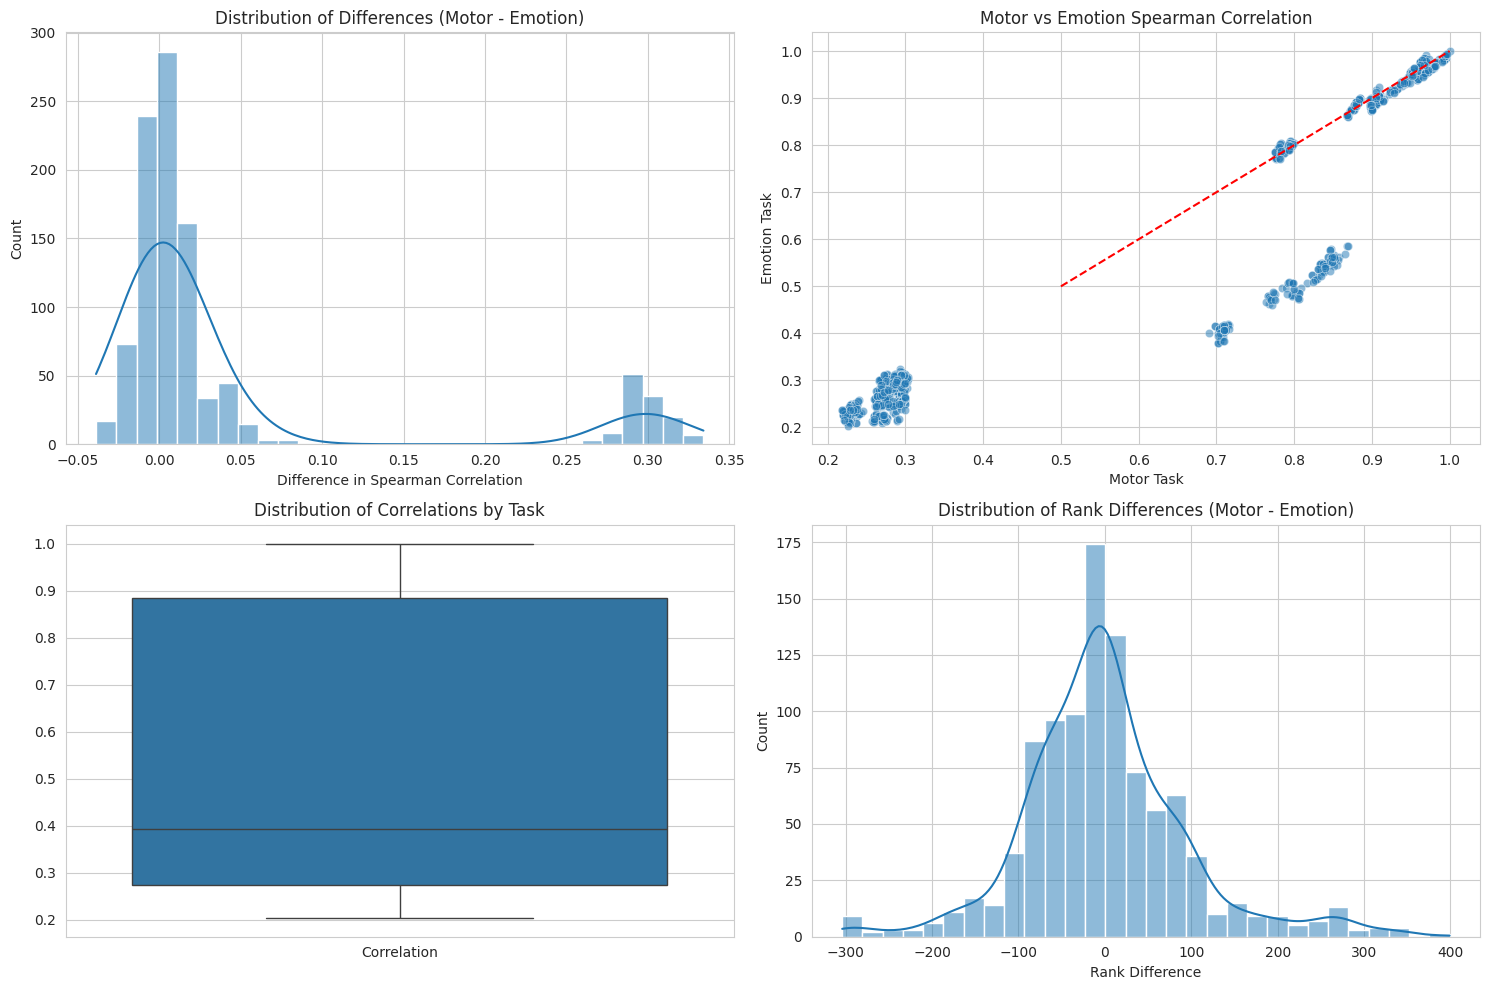

Summary Statistics:
mean_diff: 0.0412
median_diff: 0.0046
std_diff: 0.0986
min_diff: -0.0389
max_diff: 0.3341

Wilcoxon signed-rank test p-value: 0.0000


In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from scipy import stats

datadir = "/home/ymerel/fmri/OHBM_2026_neurovariants/data"
ds_path = os.path.join(datadir, 'dataset.csv')
motor_1000 = pd.read_csv(os.path.join(datadir, 'motor_1000', 'dataset.csv'), delimiter=';')
emotion_1000 = pd.read_csv(os.path.join(datadir, 'emotion_1000', 'dataset.csv'), delimiter=';')

# Merge the two datasets on 'id'
merged = pd.merge(motor_1000, emotion_1000, on='id', suffixes=('_motor', '_emotion'))

# Compute differences
merged['diff'] = merged['pearson_from_ref_motor'] - merged['pearson_from_ref_emotion']
merged['abs_diff'] = merged['diff'].abs()

# Summary statistics
summary = {
    'mean_diff': merged['diff'].mean(),
    'median_diff': merged['diff'].median(),
    'std_diff': merged['diff'].std(),
    'min_diff': merged['diff'].min(),
    'max_diff': merged['diff'].max(),
}

# Rank order analysis
merged['rank_motor'] = merged['pearson_from_ref_motor'].rank()
merged['rank_emotion'] = merged['pearson_from_ref_emotion'].rank()
merged['rank_diff'] = merged['rank_motor'] - merged['rank_emotion']

# Statistical testing
t_stat, p_val = stats.wilcoxon(merged['pearson_from_ref_motor'], merged['pearson_from_ref_emotion'])

# Plotting
plt.figure(figsize=(15, 10))

# Histogram of differences
plt.subplot(2, 2, 1)
sb.histplot(merged['diff'], bins=30, kde=True)
plt.title('Distribution of Differences (Motor - Emotion)')
plt.xlabel('Difference in Spearman Correlation')

# Scatter plot
plt.subplot(2, 2, 2)
sb.scatterplot(data=merged, x='pearson_from_ref_motor', y='pearson_from_ref_emotion', alpha=0.5)
plt.plot([0.5, 1], [0.5, 1], 'r--')  # Line of equality
plt.title('Motor vs Emotion Spearman Correlation')
plt.xlabel('Motor Task')
plt.ylabel('Emotion Task')

# Boxplot of correlations by task
plt.subplot(2, 2, 3)
sb.boxplot(data=pd.melt(merged, value_vars=['pearson_from_ref_motor', 'pearson_from_ref_emotion'], var_name='Task', value_name='Correlation'))
plt.title('Distribution of Correlations by Task')

# Rank differences
plt.subplot(2, 2, 4)
sb.histplot(merged['rank_diff'], bins=30, kde=True)
plt.title('Distribution of Rank Differences (Motor - Emotion)')
plt.xlabel('Rank Difference')

plt.tight_layout()
plt.show()

# Print summary
print("Summary Statistics:")
for k, v in summary.items():
    print(f"{k}: {v:.4f}")
print(f"\nWilcoxon signed-rank test p-value: {p_val:.4f}")
